In [17]:
import numpy as np
import pandas as pd
import pickle 
import importlib
import run_ql_pb_opt
importlib.reload(run_ql_pb_opt)
from run_ql_pb_opt import ql_pb_opt

d = pickle.load(open('../data/hospitalizations/preprocess_data_medianinterp_weekly.pkl', 'rb'))
forecasts_dict = d['forecasts_dict']
f_list = d['forecaster_list']
alpha_list = d['alpha_list']
dates_list = d['dates_list']
Y = d['Y']
T = len(dates_list)

print(f_list)
print(alpha_list)
print(dates_list)
print(Y)

['CU-select', 'GT-DeepCOVID', 'COVIDhub-4_week_ensemble', 'COVIDhub-baseline', 'Karlen-pypm', 'JHU_IDD-CovidSP', 'MOBS-GLEAM_COVID', 'USC-SI_kJalpha', 'JHUAPL-Bucky', 'JHUAPL-SLPHospEns', 'JHUAPL-Gecko', 'COVIDhub-trained_ensemble']
[0.01, 0.025, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.975, 0.99]
Index(['2021-02-23', '2021-03-02', '2021-03-09', '2021-03-16', '2021-03-23',
       '2021-03-30', '2021-04-06', '2021-04-13', '2021-04-20', '2021-04-27',
       ...
       '2023-03-28', '2023-04-04', '2023-04-11', '2023-04-18', '2023-04-25',
       '2023-05-02', '2023-05-09', '2023-05-16', '2023-05-23', '2023-05-30'],
      dtype='str', length=119)
2021-02-23    39206.0
2021-03-02    34961.0
2021-03-09    33410.0
2021-03-16    33334.0
2021-03-23    35409.0
               ...   
2023-05-02     9721.0
2023-05-09     8832.0
2023-05-16     8328.0
2023-05-23     7579.0
2023-05-30     7310.0
Name: actual, Length: 119, dtype: float64


In [29]:
def decimal_to_str(eta):
    return str(np.round(eta, 4)).replace('.', ',')
    
def exp_name_string_ql_pb(w, eta, round_Y_F, suffix):
    return f"wk{w}_eta{decimal_to_str(eta)}_{'orig_' if not round_Y_F else ''}{suffix}"

save_folder = 'hosp0315_weekly_ql_pb'
SAVE_DIR = f'../results/{save_folder}'

eta_list = np.round(np.power(10, np.arange(-4, 3.1, 0.5)), 4)
n_seed = 10
round_Y_F = False
for w in range(1, 5):
    print(f"Running wk{w}...")
    for eta_mult in eta_list:
        exp_name = exp_name_string_ql_pb(w, eta_mult, round_Y_F, 10)
        results, settings = ql_pb_opt(Y = d['Y'][d['dates_list']], 
                            forecasts_dict=forecasts_dict[w], 
                            unit=500, 
                            alpha_list=d['alpha_list'], 
                            eta_multiplier=eta_mult, 
                            seed_list=np.arange(1, n_seed+1),  
                            round_Y_F=round_Y_F
        )
        pickle.dump(results, open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'wb'))


Running wk1...


Eta: 1000.0, Seeds: 100%|██████████| 10/10 [00:00<00:00, 236.88it/s]


Running wk2...


Eta: 1000.0, Seeds: 100%|██████████| 10/10 [00:00<00:00, 223.51it/s]


Running wk3...


Eta: 1000.0, Seeds: 100%|██████████| 10/10 [00:00<00:00, 233.32it/s]


Running wk4...


Eta: 1000.0, Seeds: 100%|██████████| 10/10 [00:00<00:00, 217.55it/s]


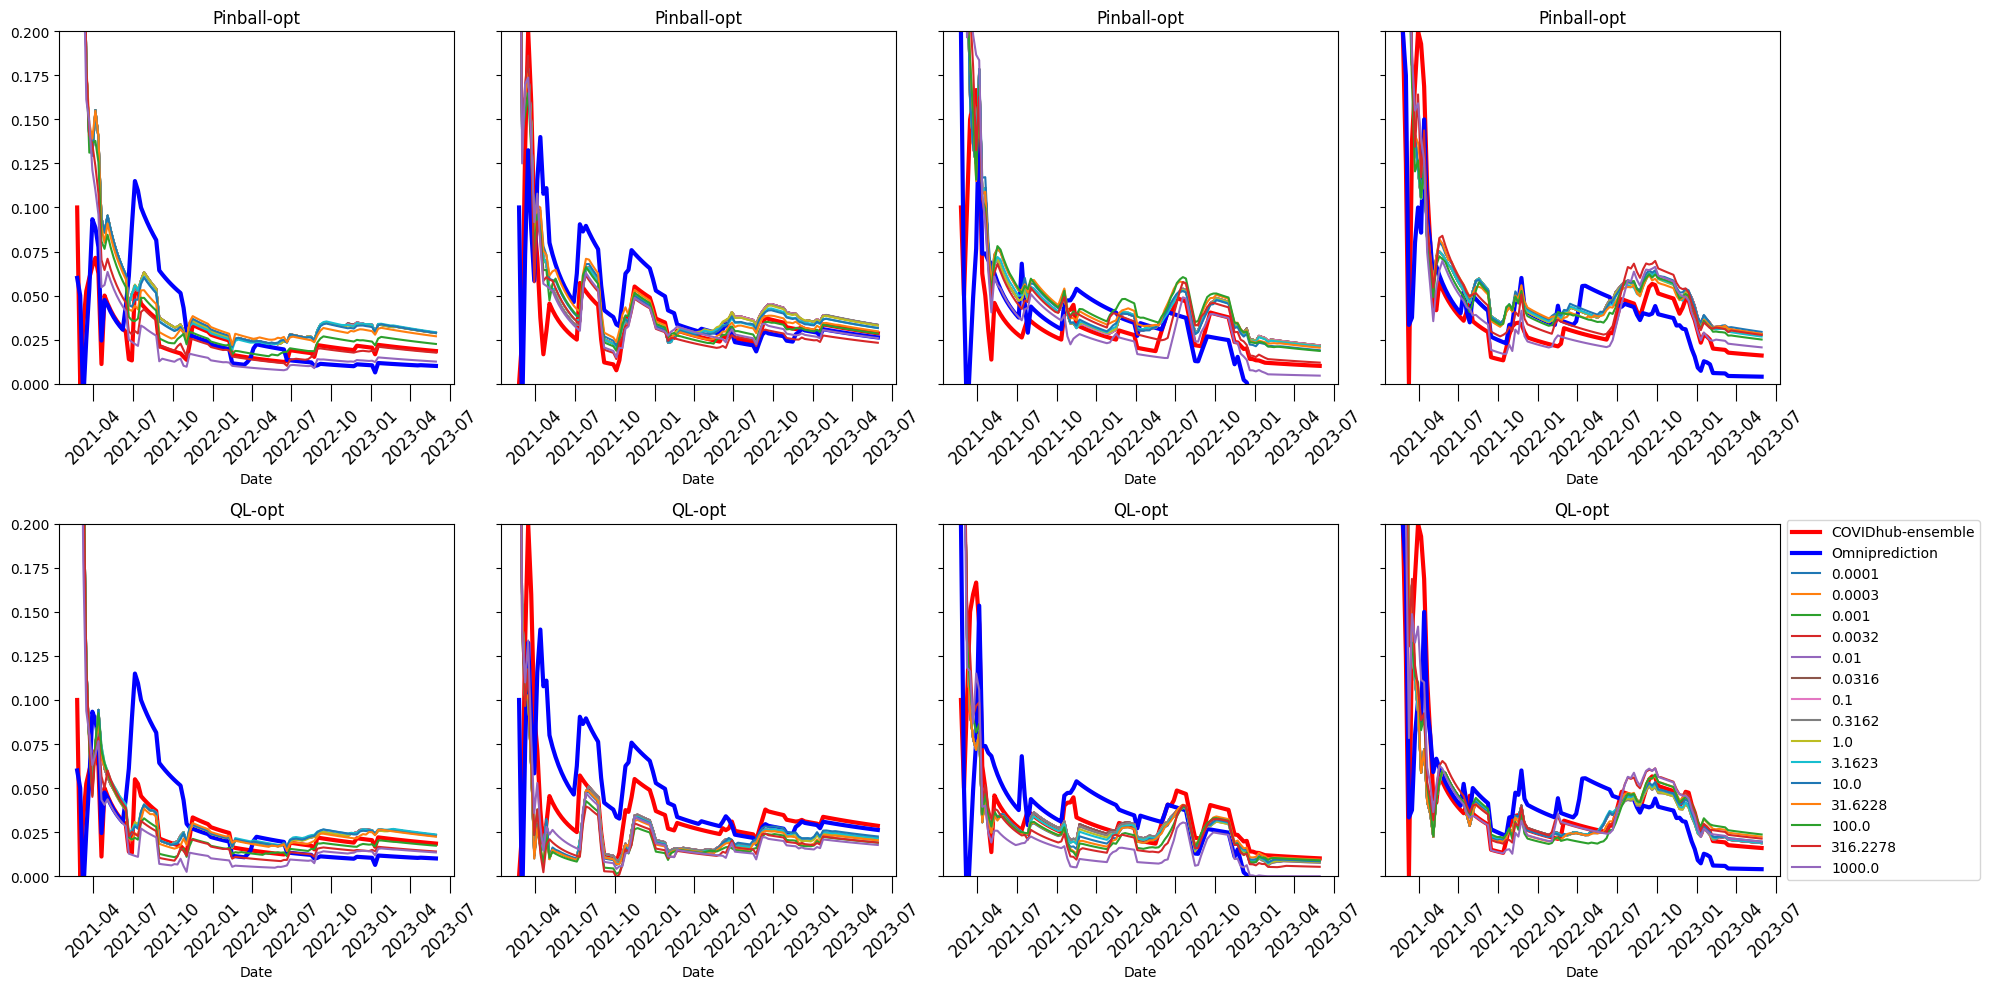

In [ ]:
#0442
import matplotlib.pyplot as plt

T = len(d['dates_list'])
dates_list = pd.to_datetime(d['dates_list'])
eta_mult = 2


fig, ax = plt.subplots(2, 4, figsize=(20, 10), sharey=True)



from run_omni_v2 import OmniResult

def exp_name_string_v2(w, eta, seed):
    return f"wk{w}_eta{decimal_to_str(eta)}_seed{seed}"

SAVE_DIR_omni = f'../results/hosp0315_weekly_v2'

for w in range(1,5):
    omni_rel_trace = np.zeros((T,))
    for seed in range(1, n_seed+1):
        exp_name = exp_name_string_v2(w, eta_mult, seed)
        results = pickle.load(open(f"{SAVE_DIR_omni}/results_{exp_name}.pkl", 'rb'))
        omni_result = OmniResult(results)
        bfst = omni_result.results['best_forecaster_score_trace']
        omni_rel_trace += (omni_result.results['omni_score_trace'] - bfst)
    
    omni_rel_trace /= n_seed
    ens_omni_rel_trace = (omni_result.ensemble_omni_score_trace - bfst)

    for iax in range(2):
        ax[iax, w-1].plot(dates_list, ens_omni_rel_trace, color='red', linewidth=3, label='COVIDhub-ensemble')
        ax[iax, w-1].plot(dates_list, omni_rel_trace, color='blue', linewidth=3, label='Omniprediction')
        ax[iax, w-1].tick_params(axis='x', labelrotation=45, labelsize=12, size=12)




for w in range(1, 5):
    for eta_mult in eta_list:
        exp_name = exp_name_string_ql_pb(w, eta_mult, 10)
        results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'rb'))
        
        pinball_omni_score_trace_rel = np.zeros(T)
        ql_omni_score_trace_rel = np.zeros(T)

        for seed in range(1, 11):
            pinball_omni_score_trace_rel += results[seed]['pinball_omni_score_trace_rel']
            ql_omni_score_trace_rel += results[seed]['ql_omni_score_trace_rel']
        
        pinball_omni_score_trace_rel /= 10
        ql_omni_score_trace_rel /= 10

        ax[0, w-1].plot(dates_list, pinball_omni_score_trace_rel, label=eta_mult)
        ax[1, w-1].plot(dates_list, ql_omni_score_trace_rel, label=eta_mult)

        ax[0, w-1].set_title(f'Pinball-opt')
        ax[1, w-1].set_title(f'QL-opt')

    ax[0, w-1].set_xlabel('Date')
    ax[1, w-1].set_xlabel('Date')

    ax[0, w-1].set_ylim(0, 0.2)
    ax[1, w-1].set_ylim(0, 0.2)

    ax[1, 3].legend(loc='center left', bbox_to_anchor=(1, 0.5))

fig.tight_layout()
plt.show()
